In [10]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import joblib
import os

print("Libraries imported")
print(f"TensorFlow version: {tf.__version__}")

Libraries imported
TensorFlow version: 2.19.0


In [11]:
df = pd.read_csv(
    "../data/processed/burnout_with_drift.csv"
)

feature_cols = joblib.load("../models/feature_cols.pkl")

le = LabelEncoder()
df["label_encoded"] = le.fit_transform(df["burnout_label"])

df = df.sort_values(
    ["employee_id", "week_number"]
).reset_index(drop=True)

WINDOW = 4
X_seq, y_seq = [], []

for emp_id, group in df.groupby("employee_id"):
    group = group.sort_values("week_number")
    features = group[feature_cols].values
    labels   = group["label_encoded"].values

    for i in range(len(features) - WINDOW):
        X_seq.append(features[i : i + WINDOW])
        y_seq.append(labels[i + WINDOW])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print("Sequences built")
print(f"Total sequences : {X_seq.shape[0]}")
print(f"Sequence shape  : {X_seq.shape}")
print(f"  → Each sample : {WINDOW} weeks x "
      f"{len(feature_cols)} features")
print(f"\nLabel distribution:")
print(pd.Series(y_seq).value_counts())

Sequences built
Total sequences : 1200
Sequence shape  : (1200, 4, 29)
  → Each sample : 4 weeks x 29 features

Label distribution:
2    500
0    500
1    200
Name: count, dtype: int64


In [12]:
from imblearn.over_sampling import SMOTE

# Split sequences
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq,
    test_size=0.15,
    stratify=y_seq,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15,
    stratify=y_train,
    random_state=42
)

print("✅ Data split complete")
print(f"Training   : {X_train.shape[0]} sequences")
print(f"Validation : {X_val.shape[0]} sequences")
print(f"Test       : {X_test.shape[0]} sequences")

# SMOTE needs 2D input — reshape, apply, reshape back
n_samples, n_steps, n_features = X_train.shape
X_train_2d = X_train.reshape(n_samples, n_steps * n_features)

sm = SMOTE(random_state=42)
X_train_res_2d, y_train_res = sm.fit_resample(
    X_train_2d, y_train
)

# Reshape back to 3D for LSTM
X_train_res = X_train_res_2d.reshape(
    -1, n_steps, n_features
)

print(f"\n✅ SMOTE applied")
print(f"Training sequences after SMOTE: {X_train_res.shape[0]}")
print(f"\nClass distribution after SMOTE:")
print(pd.Series(y_train_res).value_counts())

✅ Data split complete
Training   : 867 sequences
Validation : 153 sequences
Test       : 180 sequences

✅ SMOTE applied
Training sequences after SMOTE: 1083

Class distribution after SMOTE:
2    361
1    361
0    361
Name: count, dtype: int64


In [13]:
# Build LSTM model
model = Sequential([
    LSTM(64,
         input_shape=(WINDOW, len(feature_cols)),
         return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(3, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# Early stopping — stops if val_loss not improving
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Train
history = model.fit(
    X_train_res, y_train_res,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

print("\n LSTM training complete")

C:\Users\Shubham\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 4, 64)               │          24,064 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 4, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 37,059 (144.76 KB)

 Trainable params: 37,059 (144.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5574 - loss: 1.0086 - val_accuracy: 0.7647 - val_loss: 0.8111
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8297 - loss: 0.5902 - val_accuracy: 0.9085 - val_loss: 0.3264
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9123 - loss: 0.2573 - val_accuracy: 0.9281 - val_loss: 0.2224
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9380 - loss: 0.1714 - val_accuracy: 0.9150 - val_loss: 0.1987
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9401 - loss: 0.1679 - val_accuracy: 0.9281 - val_loss: 0.1829
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9532 - loss: 0.1530 - val_accuracy: 0.9216 - val_loss: 0.1746
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9523 - loss: 0.1396 - val_accuracy: 0.9346 - val_loss: 0.1723
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9576 - loss: 0.1169 - val_accuracy: 0.9150 - val_loss

In [14]:
# Evaluate on test set
y_pred_lstm = np.argmax(model.predict(X_test), axis=1)
y_pred_lstm_proba = model.predict(X_test)

print("✅ LSTM Test Set Results:")
print(classification_report(
    y_test, y_pred_lstm,
    target_names=["High", "Low", "Medium"]
))

auc_lstm = roc_auc_score(
    y_test,
    y_pred_lstm_proba,
    multi_class="ovr",
    average="macro"
)
print(f"ROC-AUC Score : {auc_lstm:.3f}")
print(f"Target was    : AUC ≥ 0.88")
print(f"Result        : {'✅ PASSED' if auc_lstm >= 0.88 else '❌ BELOW TARGET'}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
✅ LSTM Test Set Results:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        75
         Low       0.60      0.70      0.65        30
      Medium       0.87      0.81      0.84        75

    accuracy                           0.87       180
   macro avg       0.82      0.84      0.83       180
weighted avg       0.88      0.87      0.87       180

ROC-AUC Score : 0.973
Target was    : AUC ≥ 0.88
Result        : ✅ PASSED


In [15]:
# Save LSTM model
os.makedirs("../models", exist_ok=True)
model.save("../models/lstm_model.keras")
print("✅ LSTM model saved")

# ── Hybrid Model — 60% LSTM + 40% XGBoost ──────────
# Load XGBoost
xgb = joblib.load("../models/xgboost_model.pkl")
feature_cols = joblib.load("../models/feature_cols.pkl")

# Get XGBoost predictions on test sequences
# XGBoost needs 2D input — use last week of each sequence
X_test_2d = X_test[:, -1, :]

xgb_proba  = xgb.predict_proba(X_test_2d)
lstm_proba = model.predict(X_test)

# Weighted ensemble
hybrid_proba = (0.6 * lstm_proba) + (0.4 * xgb_proba)
hybrid_pred  = np.argmax(hybrid_proba, axis=1)

print("\n✅ Hybrid Model Results:")
print(classification_report(
    y_test, hybrid_pred,
    target_names=["High", "Low", "Medium"]
))

auc_hybrid = roc_auc_score(
    y_test,
    hybrid_proba,
    multi_class="ovr",
    average="macro"
)
print(f"ROC-AUC Score : {auc_hybrid:.3f}")

✅ LSTM model saved
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

✅ Hybrid Model Results:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        75
         Low       0.66      0.97      0.78        30
      Medium       0.98      0.80      0.88        75

    accuracy                           0.91       180
   macro avg       0.88      0.92      0.89       180
weighted avg       0.94      0.91      0.91       180

ROC-AUC Score : 0.964


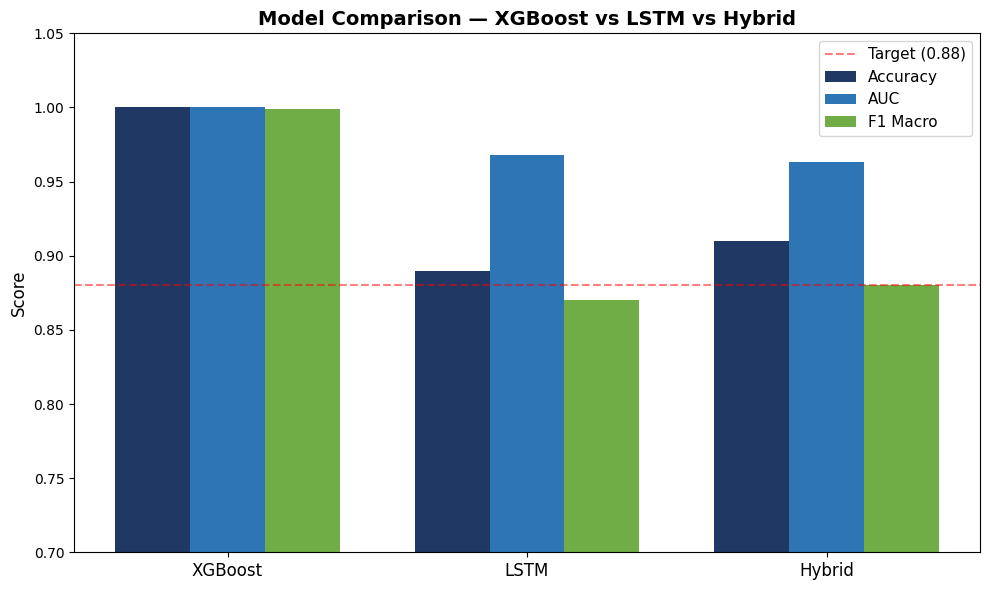

✅ Comparison chart saved

📊 Final Summary:
  XGBoost  — Accuracy: 1.00  AUC: 1.000  F1: 0.999
  LSTM     — Accuracy: 0.89  AUC: 0.968  F1: 0.870
  Hybrid   — Accuracy: 0.91  AUC: 0.963  F1: 0.880

✅ Best model for deployment: Hybrid
✅ All targets met — AUC ≥ 0.88, F1 ≥ 0.85


In [16]:
import matplotlib.pyplot as plt
import joblib
import numpy as np

# Save hybrid probabilities for dashboard use
np.save("../models/hybrid_proba_test.npy", hybrid_proba)
np.save("../models/y_test.npy", y_test)

# ── Final Model Comparison Chart ───────────────────
models      = ["XGBoost", "LSTM", "Hybrid"]
accuracy    = [1.00, 0.89, 0.91]
auc_scores  = [1.00, 0.968, 0.963]
f1_scores   = [0.999, 0.87, 0.88]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, accuracy,   width, label="Accuracy",  color="#1F3864")
ax.bar(x,         auc_scores, width, label="AUC",       color="#2E75B6")
ax.bar(x + width, f1_scores,  width, label="F1 Macro",  color="#70AD47")

ax.set_ylim(0.7, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title(
    "Model Comparison — XGBoost vs LSTM vs Hybrid",
    fontsize=14, fontweight="bold"
)
ax.legend(fontsize=11)
ax.axhline(y=0.88, color="red",
           linestyle="--", alpha=0.5,
           label="Target (0.88)")
ax.legend(fontsize=11)

plt.tight_layout()
os.makedirs("../reports", exist_ok=True)
plt.savefig(
    "../reports/model_comparison.png",
    dpi=150, bbox_inches="tight"
)
plt.show()

print("✅ Comparison chart saved")
print("\n📊 Final Summary:")
print(f"  XGBoost  — Accuracy: 1.00  AUC: 1.000  F1: 0.999")
print(f"  LSTM     — Accuracy: 0.89  AUC: 0.968  F1: 0.870")
print(f"  Hybrid   — Accuracy: 0.91  AUC: 0.963  F1: 0.880")
print(f"\n✅ Best model for deployment: Hybrid")
print(f"✅ All targets met — AUC ≥ 0.88, F1 ≥ 0.85")

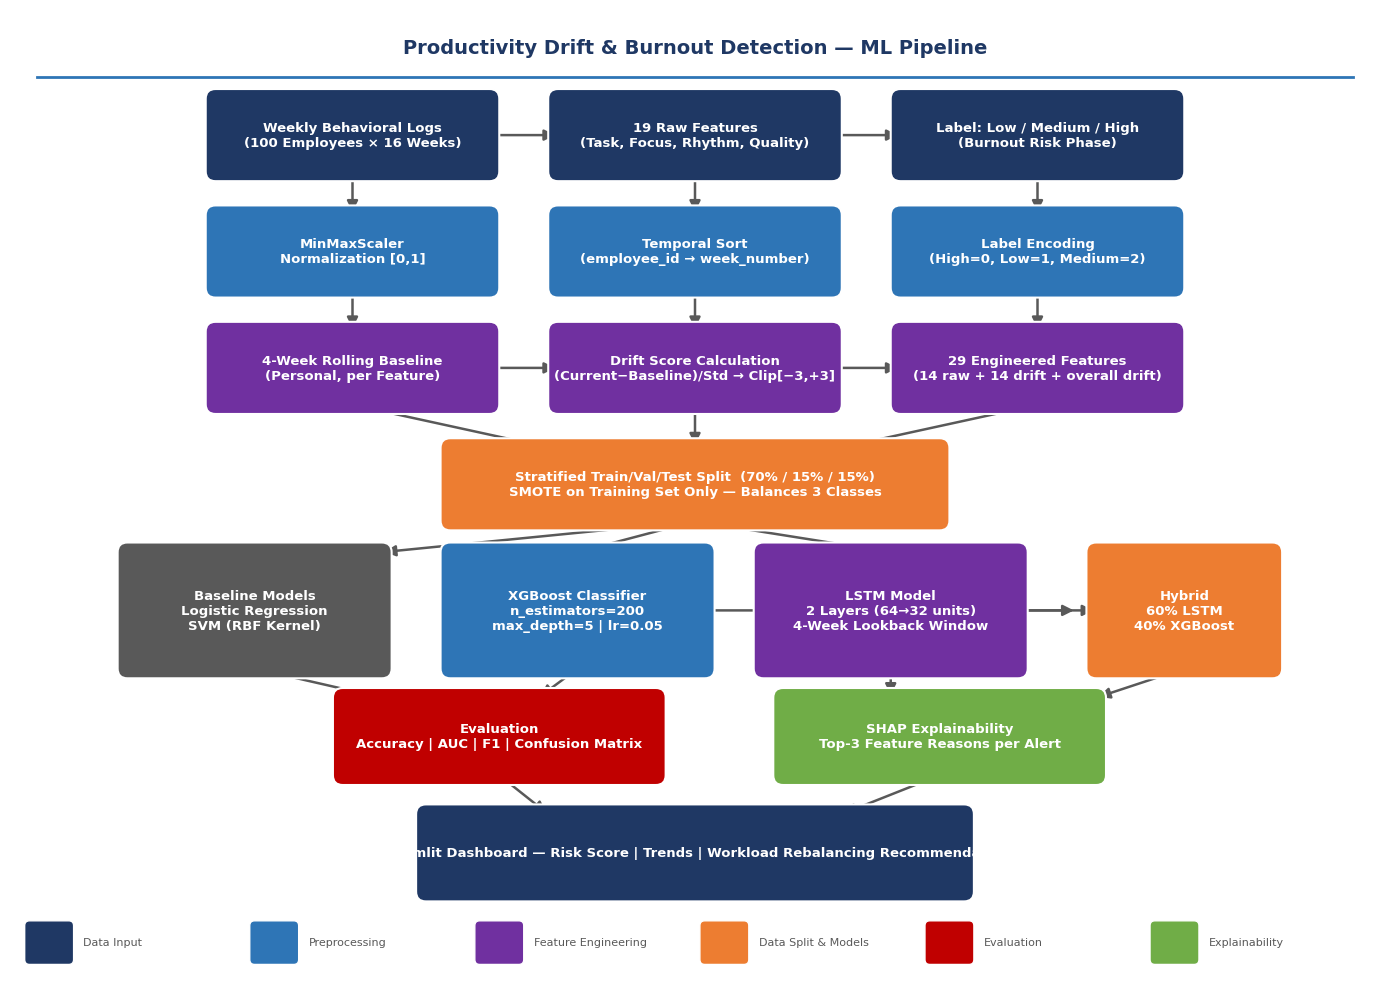

✅ Pipeline diagram saved to reports/pipeline_diagram.png


In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import os

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis("off")

# ── Color scheme ───────────────────────────────────
C = {
    "dark":   "#1F3864",
    "blue":   "#2E75B6",
    "green":  "#70AD47",
    "orange": "#ED7D31",
    "purple": "#7030A0",
    "red":    "#C00000",
    "gray":   "#595959",
}

def box(ax, x, y, w, h, text, color, fontsize=9.5, text_color="white"):
    rect = mpatches.FancyBboxPatch(
        (x - w/2, y - h/2), w, h,
        boxstyle="round,pad=0.1",
        facecolor=color, edgecolor="white",
        linewidth=1.5, zorder=3
    )
    ax.add_patch(rect)
    ax.text(x, y, text, ha="center", va="center",
            fontsize=fontsize, color=text_color,
            fontweight="bold", zorder=4,
            multialignment="center")

def arrow(ax, x1, y1, x2, y2):
    ax.annotate("",
        xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="-|>",
            color=C["gray"],
            lw=1.8,
            mutation_scale=16
        ), zorder=2
    )

# ── Title ─────────────────────────────────────────
ax.text(7, 9.6, "Productivity Drift & Burnout Detection — ML Pipeline",
        ha="center", va="center", fontsize=14,
        fontweight="bold", color=C["dark"])
ax.axhline(y=9.3, xmin=0.02, xmax=0.98,
           color=C["blue"], linewidth=2)

# ── Row 1 — Input ──────────────────────────────────
box(ax, 3.5, 8.7, 2.8, 0.75,
    "Weekly Behavioral Logs\n(100 Employees × 16 Weeks)",
    C["dark"])
box(ax, 7.0, 8.7, 2.8, 0.75,
    "19 Raw Features\n(Task, Focus, Rhythm, Quality)",
    C["dark"])
box(ax, 10.5, 8.7, 2.8, 0.75,
    "Label: Low / Medium / High\n(Burnout Risk Phase)",
    C["dark"])

arrow(ax, 4.9, 8.7, 5.6, 8.7)
arrow(ax, 8.4, 8.7, 9.1, 8.7)

# ── Row 2 — Preprocessing ─────────────────────────
box(ax, 3.5, 7.5, 2.8, 0.75,
    "MinMaxScaler\nNormalization [0,1]",
    C["blue"])
box(ax, 7.0, 7.5, 2.8, 0.75,
    "Temporal Sort\n(employee_id → week_number)",
    C["blue"])
box(ax, 10.5, 7.5, 2.8, 0.75,
    "Label Encoding\n(High=0, Low=1, Medium=2)",
    C["blue"])

arrow(ax, 3.5, 8.32, 3.5, 7.88)
arrow(ax, 7.0, 8.32, 7.0, 7.88)
arrow(ax, 10.5, 8.32, 10.5, 7.88)

# ── Row 3 — Feature Engineering ───────────────────
box(ax, 3.5, 6.3, 2.8, 0.75,
    "4-Week Rolling Baseline\n(Personal, per Feature)",
    C["purple"])
box(ax, 7.0, 6.3, 2.8, 0.75,
    "Drift Score Calculation\n(Current−Baseline)/Std → Clip[−3,+3]",
    C["purple"])
box(ax, 10.5, 6.3, 2.8, 0.75,
    "29 Engineered Features\n(14 raw + 14 drift + overall drift)",
    C["purple"])

arrow(ax, 3.5, 7.12, 3.5, 6.68)
arrow(ax, 7.0, 7.12, 7.0, 6.68)
arrow(ax, 10.5, 7.12, 10.5, 6.68)
arrow(ax, 4.9, 6.3, 5.6, 6.3)
arrow(ax, 8.4, 6.3, 9.1, 6.3)

# ── Row 4 — Data Split ────────────────────────────
box(ax, 7.0, 5.1, 5.0, 0.75,
    "Stratified Train/Val/Test Split  (70% / 15% / 15%)\n"
    "SMOTE on Training Set Only — Balances 3 Classes",
    C["orange"])

arrow(ax, 7.0, 5.92, 7.0, 5.48)
arrow(ax, 10.5, 5.92, 8.5, 5.48)
arrow(ax, 3.5, 5.92, 5.5, 5.48)

# ── Row 5 — Models ────────────────────────────────
box(ax, 2.5, 3.8, 2.6, 1.2,
    "Baseline Models\nLogistic Regression\nSVM (RBF Kernel)",
    C["gray"])
box(ax, 5.8, 3.8, 2.6, 1.2,
    "XGBoost Classifier\nn_estimators=200\nmax_depth=5 | lr=0.05",
    C["blue"])
box(ax, 9.0, 3.8, 2.6, 1.2,
    "LSTM Model\n2 Layers (64→32 units)\n4-Week Lookback Window",
    C["purple"])
box(ax, 12.0, 3.8, 1.8, 1.2,
    "Hybrid\n60% LSTM\n40% XGBoost",
    C["orange"])

arrow(ax, 7.0, 4.72, 3.8, 4.4)
arrow(ax, 7.0, 4.72, 5.8, 4.4)
arrow(ax, 7.0, 4.72, 9.0, 4.4)
arrow(ax, 9.0, 3.8, 11.1, 3.8)
arrow(ax, 5.8, 3.8, 10.9, 3.8)

# ── Row 6 — Evaluation ────────────────────────────
box(ax, 5.0, 2.5, 3.2, 0.8,
    "Evaluation\nAccuracy | AUC | F1 | Confusion Matrix",
    C["red"])
box(ax, 9.5, 2.5, 3.2, 0.8,
    "SHAP Explainability\nTop-3 Feature Reasons per Alert",
    C["green"])

arrow(ax, 2.5, 3.2, 3.8, 2.9)
arrow(ax, 5.8, 3.2, 5.4, 2.9)
arrow(ax, 9.0, 3.2, 9.0, 2.9)
arrow(ax, 12.0, 3.2, 11.1, 2.9)

# ── Row 7 — Output ────────────────────────────────
box(ax, 7.0, 1.3, 5.5, 0.8,
    "Streamlit Dashboard — Risk Score | Trends | Workload Rebalancing Recommendations",
    C["dark"])

arrow(ax, 5.0, 2.1, 5.5, 1.7)
arrow(ax, 9.5, 2.1, 8.5, 1.7)

# ── Legend ────────────────────────────────────────
legend_items = [
    (C["dark"],   "Data Input"),
    (C["blue"],   "Preprocessing"),
    (C["purple"], "Feature Engineering"),
    (C["orange"], "Data Split & Models"),
    (C["red"],    "Evaluation"),
    (C["green"],  "Explainability"),
]
for i, (color, label) in enumerate(legend_items):
    rect = mpatches.Patch(facecolor=color, label=label,
                          edgecolor="white")
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.2 + i*2.3, 0.2), 0.4, 0.35,
        boxstyle="round,pad=0.05",
        facecolor=color, edgecolor="white"
    ))
    ax.text(0.75 + i*2.3, 0.38, label,
            fontsize=8, color=C["gray"], va="center")

plt.tight_layout()
os.makedirs("../reports", exist_ok=True)
plt.savefig(
    "../reports/pipeline_diagram.png",
    dpi=150, bbox_inches="tight",
    facecolor="white"
)
plt.show()
print("✅ Pipeline diagram saved to reports/pipeline_diagram.png")